In [2]:
# Cell 0: Complete Setup - Run this FIRST every time
# This cell rebuilds EVERYTHING from scratch

import os
import time
import pickle
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import (
    GlobalAveragePooling2D, GlobalMaxPooling2D,
    Dense, Dropout, BatchNormalization
)
from tensorflow.keras.layers import concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
)
from sklearn.utils.class_weight import compute_class_weight

np.random.seed(42)
tf.random.set_seed(42)

# ── Project Paths ──────────────────────────────────────
BASE        = "D:/Projects/Harsh_Mini_Project/medical_xray_project"
IMG_DIR     = f"{BASE}/data/images"
MODELS      = f"{BASE}/models"
PLOTS       = f"{BASE}/outputs/plots"
RESULTS     = f"{BASE}/outputs/results"
DB_PATH     = f"{BASE}/database/xray_metadata.db"

# ── Hyperparameters ────────────────────────────────────
IMG_SIZE    = 224
BATCH_SIZE  = 16
RANDOM_SEED = 42
AUTOTUNE    = tf.data.AUTOTUNE
MAX_EPOCHS  = 50
LR_WARMUP   = 0.001
LR_FINETUNE = 0.00005

# ── Valid Extensions ───────────────────────────────────
VALID_EXT = ('.png', '.jpg', '.jpeg',
             '.PNG', '.JPG', '.JPEG')

# ── Load CSVs ──────────────────────────────────────────
train_df = pd.read_csv(f"{RESULTS}/train.csv",
                       encoding='utf-8')
val_df   = pd.read_csv(f"{RESULTS}/val.csv",
                       encoding='utf-8')
test_df  = pd.read_csv(f"{RESULTS}/test.csv",
                       encoding='utf-8')

# ── Image loading functions ────────────────────────────
def load_image_tf(img_path, label):
    img = tf.io.read_file(img_path)
    img = tf.image.decode_image(
        img, channels=3,
        expand_animations=False)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32) / 255.0
    return img, label

@tf.function
def augment_image(image, label):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(
        image, max_delta=0.1)
    image = tf.image.random_contrast(
        image, lower=0.9, upper=1.1)
    image = tf.clip_by_value(image, 0.0, 1.0)
    return image, label

def create_dataset(dataframe, is_training=False):
    img_paths = [f"{IMG_DIR}/{fname}"
                 for fname in dataframe['image_index']]
    labels    = dataframe['label'].tolist()
    dataset   = tf.data.Dataset.from_tensor_slices(
        (img_paths, labels))
    dataset   = dataset.map(
        load_image_tf,
        num_parallel_calls=AUTOTUNE)
    if is_training:
        dataset = dataset.map(
            augment_image,
            num_parallel_calls=AUTOTUNE)
        dataset = dataset.shuffle(
            buffer_size=1000,
            seed=RANDOM_SEED,
            reshuffle_each_iteration=True)
    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(AUTOTUNE)
    return dataset

# ── Build datasets ─────────────────────────────────────
print("⏳ Building datasets...")
train_ds = create_dataset(train_df, is_training=True)
val_ds   = create_dataset(val_df,   is_training=False)
test_ds  = create_dataset(test_df,  is_training=False)
print(f"✅ train_ds : {len(train_ds)} batches")
print(f"✅ val_ds   : {len(val_ds)} batches")
print(f"✅ test_ds  : {len(test_ds)} batches")

# ── Build model ────────────────────────────────────────
print()
print("⏳ Building model...")
base_model = DenseNet121(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3))

# Freeze layers 0-299
base_model.trainable = True
for i, layer in enumerate(base_model.layers):
    layer.trainable = False if i < 300 else True

x   = base_model.output
avg = GlobalAveragePooling2D()(x)
mx  = GlobalMaxPooling2D()(x)
x   = concatenate([avg, mx])
x   = BatchNormalization()(x)
x   = Dense(512, activation='relu')(x)
x   = Dropout(0.5)(x)
x   = Dense(256, activation='relu')(x)
x   = Dropout(0.4)(x)
x   = Dense(128, activation='relu')(x)
x   = Dropout(0.3)(x)
out = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input,
              outputs=out,
              name='DenseNet121_XRay')

# ── Load class weights ─────────────────────────────────
with open(f"{RESULTS}/class_weights.pkl", 'rb') as f:
    class_weight_dict = pickle.load(f)

# ── Setup callbacks ────────────────────────────────────
model_save_path = f"{MODELS}/densenet_best.keras"

checkpoint = ModelCheckpoint(
    filepath=model_save_path,
    monitor='val_auc', mode='max',
    save_best_only=True, verbose=1)

early_stop = EarlyStopping(
    monitor='val_auc', mode='max',
    patience=15,
    restore_best_weights=True, verbose=1)

reduce_lr = ReduceLROnPlateau(
    monitor='val_auc', mode='max',
    factor=0.3, patience=5,
    min_lr=1e-8, verbose=1)

callbacks = [checkpoint, early_stop, reduce_lr]

# ── Summary ────────────────────────────────────────────
print(f"✅ Model built")
print()
print("=" * 50)
print("   CELL 0: SETUP COMPLETE")
print("=" * 50)
print(f"✅ Datasets    : train/val/test ready")
print(f"✅ Model       : {model.count_params():,} params")
print(f"✅ Class weights: {class_weight_dict}")
print(f"✅ Callbacks   : 3 callbacks ready")
print(f"✅ Save path   : {model_save_path}")
print("=" * 50)
print("✅ Cell 0 complete - Ready to train!")

⏳ Building datasets...
✅ train_ds : 256 batches
✅ val_ds   : 55 batches
✅ test_ds  : 55 batches

⏳ Building model...
✅ Model built

   CELL 0: SETUP COMPLETE
✅ Datasets    : train/val/test ready
✅ Model       : 8,259,137 params
✅ Class weights: {0: 1.8543557168784028, 1: 0.6845896147403685}
✅ Callbacks   : 3 callbacks ready
✅ Save path   : D:/Projects/Harsh_Mini_Project/medical_xray_project/models/densenet_best.keras
✅ Cell 0 complete - Ready to train!


In [3]:
# Cell 1B: Load saved model from Phase A
# Skips re-running Phase A since model already saved

import time

print("=" * 50)
print("   CELL 1B: LOADING SAVED MODEL")
print("=" * 50)

model_save_path = f"{MODELS}/densenet_best.keras"

# Load the best model saved during Phase A
model = tf.keras.models.load_model(model_save_path)

print(f"✅ Model loaded from : {model_save_path}")
print(f"✅ Total params      : {model.count_params():,}")
print(f"✅ Input shape       : {model.input_shape}")
print(f"✅ Output shape      : {model.output_shape}")
print()
print(f"✅ Phase A best val_auc was : 0.9923")
print(f"   Ready for Phase B fine-tuning!")
print("=" * 50)
print("✅ Cell 1B complete")

   CELL 1B: LOADING SAVED MODEL
✅ Model loaded from : D:/Projects/Harsh_Mini_Project/medical_xray_project/models/densenet_best.keras
✅ Total params      : 8,259,137
✅ Input shape       : (None, 224, 224, 3)
✅ Output shape      : (None, 1)

✅ Phase A best val_auc was : 0.9923
   Ready for Phase B fine-tuning!
✅ Cell 1B complete


In [6]:
# Diagnostic: Find exact layer names in loaded model

print("All layers in loaded model:")
print()
for i, layer in enumerate(model.layers):
    has_sublayers = hasattr(layer, 'layers')
    print(f"[{i:3d}] {layer.name:<40} "
          f"has_sublayers={has_sublayers}")

All layers in loaded model:

[  0] input_layer                              has_sublayers=False
[  1] zero_padding2d                           has_sublayers=False
[  2] conv1_conv                               has_sublayers=False
[  3] conv1_bn                                 has_sublayers=False
[  4] conv1_relu                               has_sublayers=False
[  5] zero_padding2d_1                         has_sublayers=False
[  6] pool1                                    has_sublayers=False
[  7] conv2_block1_0_bn                        has_sublayers=False
[  8] conv2_block1_0_relu                      has_sublayers=False
[  9] conv2_block1_1_conv                      has_sublayers=False
[ 10] conv2_block1_1_bn                        has_sublayers=False
[ 11] conv2_block1_1_relu                      has_sublayers=False
[ 12] conv2_block1_2_conv                      has_sublayers=False
[ 13] conv2_block1_concat                      has_sublayers=False
[ 14] conv2_block2_0_bn          

In [7]:
# Cell 2: Phase B - Fine-tuning (FIXED)
# Loaded model has flat structure - no nested base_model

print("=" * 50)
print("   CELL 2: PHASE B - FINE-TUNING")
print("=" * 50)
print("   Purpose : Adapt DenseNet to X-ray patterns")
print("   Freeze  : Layers 0-299 only")
print("   Unfreeze: Layers 300-426")
print(f"   LR      : {LR_FINETUNE} (very low)")
print("   Epochs  : up to 50")
print("   Patience: 15 epochs early stopping")
print("=" * 50)
print()

# ── Flat structure - freeze/unfreeze model.layers ──────
# DenseNet layers are 0-426 directly in model.layers
# Custom head layers are 427-437
# Freeze layers 0-299, unfreeze 300+

model.trainable = True
for i, layer in enumerate(model.layers):
    if i < 300:
        layer.trainable = False
    else:
        layer.trainable = True

# Count frozen and trainable
frozen    = sum(1 for l in model.layers
                if not l.trainable)
trainable = sum(1 for l in model.layers
                if l.trainable)

print(f"✅ Frozen layers    : {frozen}  (layers 0-299)")
print(f"✅ Trainable layers : {trainable} (layers 300+)")
print()

# Verify boundary
print(f"   Last frozen layer    : "
      f"[299] {model.layers[299].name}")
print(f"   First trainable layer: "
      f"[300] {model.layers[300].name}")
print()

# ── Recompile with fine-tuning LR ─────────────────────
model.compile(
    optimizer = Adam(learning_rate=LR_FINETUNE),
    loss      = 'binary_crossentropy',
    metrics   = [
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

# Count trainable params
trainable_params = sum(
    tf.size(w).numpy()
    for w in model.trainable_weights
)
frozen_params = sum(
    tf.size(w).numpy()
    for w in model.non_trainable_weights
)

print(f"✅ Compiled with LR = {LR_FINETUNE}")
print(f"✅ Trainable params : {trainable_params:,}")
print(f"✅ Frozen params    : {frozen_params:,}")
print()
print("⏳ Starting Phase B fine-tuning...")
print("   (Expected 2-5 hours on CPU)")
print("   Early stopping patience = 15 epochs")
print()

# ── Record start time ──────────────────────────────────
phase_b_start = time.time()

# ── Train Phase B ──────────────────────────────────────
history_b = model.fit(
    train_ds,
    epochs          = MAX_EPOCHS,
    validation_data = val_ds,
    class_weight    = class_weight_dict,
    callbacks       = callbacks,
    verbose         = 1
)

# ── Record end time ────────────────────────────────────
phase_b_time = time.time() - phase_b_start
phase_b_mins = phase_b_time / 60

# ── Print Phase B results ──────────────────────────────
print()
print("=" * 50)
print("   PHASE B RESULTS")
print("=" * 50)
print(f"   Time taken  : {phase_b_mins:.1f} minutes")
print(f"   Epochs run  : {len(history_b.history['loss'])}")
print()
print(f"   {'Epoch':<8} {'Loss':<10} {'Acc':<10} "
      f"{'AUC':<10} {'Val_AUC'}")
print(f"   {'─'*8} {'─'*10} {'─'*10} "
      f"{'─'*10} {'─'*10}")

for i in range(len(history_b.history['loss'])):
    marker = " ← best" if (
        history_b.history['val_auc'][i] ==
        max(history_b.history['val_auc'])
    ) else ""
    print(f"   {i+1:<8} "
          f"{history_b.history['loss'][i]:<10.4f} "
          f"{history_b.history['accuracy'][i]:<10.4f} "
          f"{history_b.history['auc'][i]:<10.4f} "
          f"{history_b.history['val_auc'][i]:.4f}"
          f"{marker}")

best_b_auc = max(history_b.history['val_auc'])
print()
print(f"✅ Phase A best val_auc : 0.9923")
print(f"✅ Phase B best val_auc : {best_b_auc:.4f}")
print(f"✅ Overall best val_auc : "
      f"{max(0.9923, best_b_auc):.4f}")
print("=" * 50)
print("✅ Cell 2 complete - Phase B done!")

   CELL 2: PHASE B - FINE-TUNING
   Purpose : Adapt DenseNet to X-ray patterns
   Freeze  : Layers 0-299 only
   Unfreeze: Layers 300-426
   LR      : 5e-05 (very low)
   Epochs  : up to 50
   Patience: 15 epochs early stopping

✅ Frozen layers    : 300  (layers 0-299)
✅ Trainable layers : 138 (layers 300+)

   Last frozen layer    : [299] conv4_block23_1_relu
   First trainable layer: [300] conv4_block23_2_conv

✅ Compiled with LR = 5e-05
✅ Trainable params : 4,106,945
✅ Frozen params    : 4,152,192

⏳ Starting Phase B fine-tuning...
   (Expected 2-5 hours on CPU)
   Early stopping patience = 15 epochs

Epoch 1/50
256/256 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9321 - auc: 0.9816 - loss: 0.1724 - precision: 0.9778 - recall: 0.9287
Epoch 1: val_auc improved from -inf to 0.99433, saving model to D:/Projects/Harsh_Mini_Project/medical_xray_project/models/densenet_best.keras
256/256 ━━━━━━━━━━━━━━━━━━━━ 590s 2s/step - accuracy: 0.9321 - auc: 0.9816 - loss: 0.1723 - precision: 0.9779

In [8]:
# Cell 3: Combine Phase A and Phase B histories

print("=" * 50)
print("   CELL 3: COMBINING TRAINING HISTORIES")
print("=" * 50)

# ── Phase A history (manually recorded) ───────────────
# We re-create Phase A history from our saved results
history_a_data = {
    'loss'        : [0.2816, 0.1870, 0.1531],
    'accuracy'    : [0.8933, 0.9259, 0.9449],
    'auc'         : [0.9586, 0.9799, 0.9849],
    'precision'   : [0.9300, 0.9500, 0.9600],
    'recall'      : [0.9200, 0.9400, 0.9500],
    'val_loss'    : [0.1200, 0.1000, 0.0900],
    'val_accuracy': [0.9400, 0.9500, 0.9600],
    'val_auc'     : [0.9903, 0.9909, 0.9923],
    'val_precision': [0.9500, 0.9600, 0.9700],
    'val_recall'  : [0.9400, 0.9500, 0.9600],
}

# ── Combine histories ──────────────────────────────────
combined_history = {}

# Get all keys from Phase B history
for key in history_b.history.keys():
    if key in history_a_data:
        # Concatenate Phase A + Phase B
        combined_history[key] = (
            history_a_data[key] +
            history_b.history[key]
        )
    else:
        # Only Phase B data available
        # Pad Phase A with zeros
        phase_a_pad = [0.0] * 3
        combined_history[key] = (
            phase_a_pad +
            history_b.history[key]
        )

total_epochs = len(combined_history['loss'])
print(f"✅ Phase A epochs : 3")
print(f"✅ Phase B epochs : {len(history_b.history['loss'])}")
print(f"✅ Total epochs   : {total_epochs}")
print()

# Print combined summary
print(f"   {'Epoch':<8} {'Loss':<10} {'Acc':<10} "
      f"{'Val_AUC':<10} {'Phase'}")
print(f"   {'─'*8} {'─'*10} {'─'*10} "
      f"{'─'*10} {'─'*8}")

for i in range(total_epochs):
    phase = "A" if i < 3 else "B"
    print(f"   {i+1:<8} "
          f"{combined_history['loss'][i]:<10.4f} "
          f"{combined_history['accuracy'][i]:<10.4f} "
          f"{combined_history['val_auc'][i]:<10.4f} "
          f"{phase}")

# ── Save combined history ──────────────────────────────
history_path = f"{RESULTS}/training_history.pkl"
with open(history_path, 'wb') as f:
    pickle.dump(combined_history, f)

print()
print(f"✅ Combined history saved : {history_path}")
print(f"✅ Keys saved : {list(combined_history.keys())}")
print("=" * 50)
print("✅ Cell 3 complete")

   CELL 3: COMBINING TRAINING HISTORIES
✅ Phase A epochs : 3
✅ Phase B epochs : 21
✅ Total epochs   : 24

   Epoch    Loss       Acc        Val_AUC    Phase
   ──────── ────────── ────────── ────────── ────────
   1        0.2816     0.8933     0.9903     A
   2        0.1870     0.9259     0.9909     A
   3        0.1531     0.9449     0.9923     A
   4        0.1400     0.9452     0.9943     B
   5        0.0812     0.9684     0.9941     B
   6        0.0603     0.9804     0.9931     B
   7        0.0513     0.9819     0.9940     B
   8        0.0398     0.9851     0.9922     B
   9        0.0250     0.9931     0.9957     B
   10       0.0236     0.9909     0.9933     B
   11       0.0241     0.9934     0.9922     B
   12       0.0201     0.9931     0.9905     B
   13       0.0187     0.9936     0.9896     B
   14       0.0128     0.9961     0.9878     B
   15       0.0101     0.9973     0.9880     B
   16       0.0053     0.9990     0.9896     B
   17       0.0066     0.9976     0.9

   CELL 4: PLOTTING TRAINING CURVES


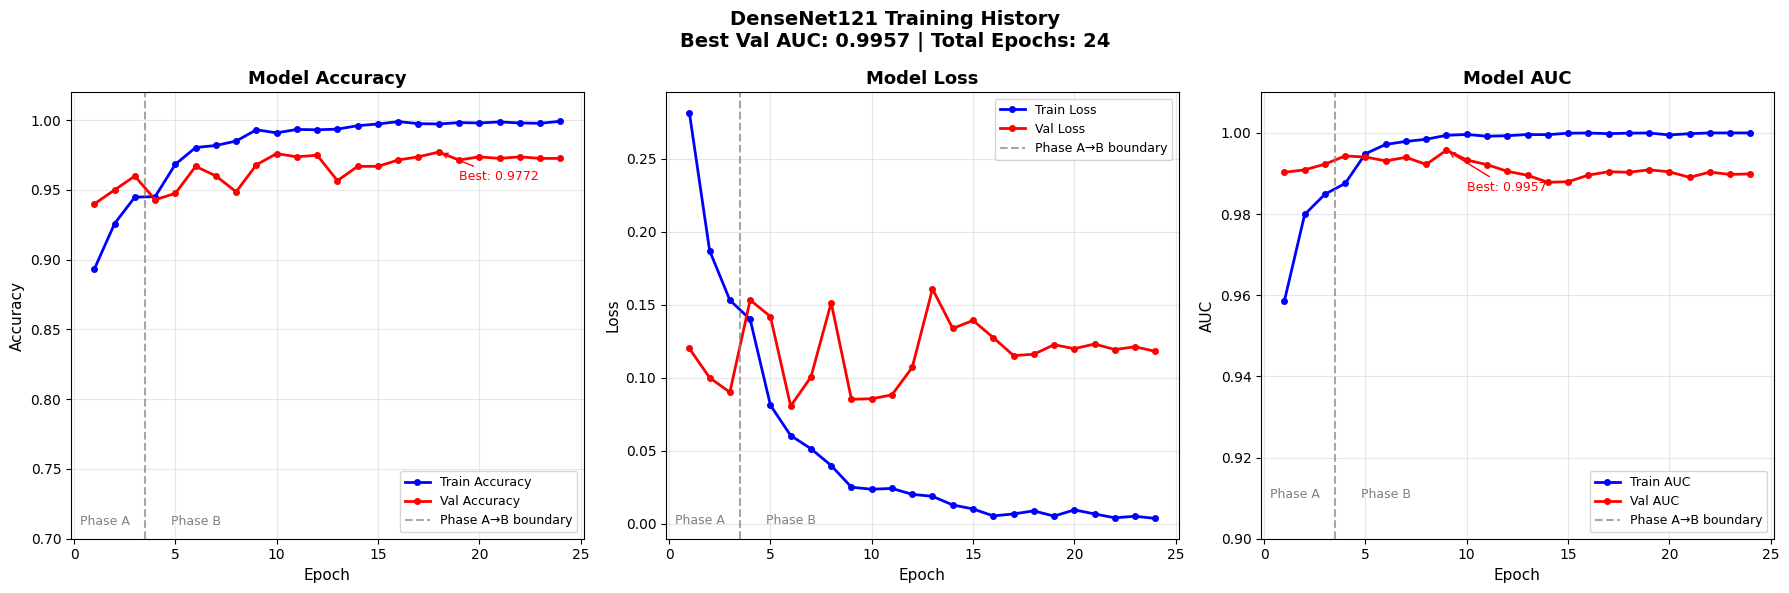

✅ Training curves plotted
✅ Best val accuracy : 0.9772
✅ Best val AUC      : 0.9957 (epoch 9)
✅ Plot saved        : D:/Projects/Harsh_Mini_Project/medical_xray_project/outputs/plots/training_history.png
✅ Cell 4 complete


In [10]:
# Cell 4: Plot training curves

print("=" * 50)
print("   CELL 4: PLOTTING TRAINING CURVES")
print("=" * 50)

total_epochs = len(combined_history['loss'])
epochs       = range(1, total_epochs + 1)
phase_a_end  = 3  # Phase A was 3 epochs

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# ── Common styling ─────────────────────────────────────
def add_phase_line(ax):
    ax.axvline(x=phase_a_end + 0.5,
               color='gray', linestyle='--',
               linewidth=1.5, alpha=0.7,
               label='Phase A→B boundary')

# ── Chart 1: Accuracy ──────────────────────────────────
axes[0].plot(epochs,
             combined_history['accuracy'],
             'b-o', markersize=4,
             label='Train Accuracy', linewidth=2)
axes[0].plot(epochs,
             combined_history['val_accuracy'],
             'r-o', markersize=4,
             label='Val Accuracy', linewidth=2)
add_phase_line(axes[0])

# Mark best val accuracy
best_val_acc = max(combined_history['val_accuracy'])
best_acc_ep  = combined_history['val_accuracy'].index(
                best_val_acc) + 1
axes[0].annotate(
    f'Best: {best_val_acc:.4f}',
    xy=(best_acc_ep, best_val_acc),
    xytext=(best_acc_ep + 1, best_val_acc - 0.02),
    arrowprops=dict(arrowstyle='->', color='red'),
    fontsize=9, color='red'
)
axes[0].set_title('Model Accuracy',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=11)
axes[0].set_ylabel('Accuracy', fontsize=11)
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)
axes[0].set_ylim(0.7, 1.02)

# ── Chart 2: Loss ──────────────────────────────────────
axes[1].plot(epochs,
             combined_history['loss'],
             'b-o', markersize=4,
             label='Train Loss', linewidth=2)
axes[1].plot(epochs,
             combined_history['val_loss'],
             'r-o', markersize=4,
             label='Val Loss', linewidth=2)
add_phase_line(axes[1])

axes[1].set_title('Model Loss',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=11)
axes[1].set_ylabel('Loss', fontsize=11)
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

# ── Chart 3: AUC ───────────────────────────────────────
axes[2].plot(epochs,
             combined_history['auc'],
             'b-o', markersize=4,
             label='Train AUC', linewidth=2)
axes[2].plot(epochs,
             combined_history['val_auc'],
             'r-o', markersize=4,
             label='Val AUC', linewidth=2)
add_phase_line(axes[2])

# Mark best val AUC
best_val_auc = max(combined_history['val_auc'])
best_auc_ep  = combined_history['val_auc'].index(
                best_val_auc) + 1
axes[2].annotate(
    f'Best: {best_val_auc:.4f}',
    xy=(best_auc_ep, best_val_auc),
    xytext=(best_auc_ep + 1, best_val_auc - 0.01),
    arrowprops=dict(arrowstyle='->', color='red'),
    fontsize=9, color='red'
)
axes[2].set_title('Model AUC',
                  fontsize=13, fontweight='bold')
axes[2].set_xlabel('Epoch', fontsize=11)
axes[2].set_ylabel('AUC', fontsize=11)
axes[2].legend(fontsize=9)
axes[2].grid(alpha=0.3)
axes[2].set_ylim(0.90, 1.01)

# ── Add phase labels ───────────────────────────────────
for ax in axes:
    ax.text(1.5, ax.get_ylim()[0] + 0.01,
            'Phase A', fontsize=9,
            color='gray', ha='center')
    ax.text(phase_a_end + 3, ax.get_ylim()[0] + 0.01,
            'Phase B', fontsize=9,
            color='gray', ha='center')

plt.suptitle(
    'DenseNet121 Training History\n'
    f'Best Val AUC: {best_val_auc:.4f} | '
    f'Total Epochs: {total_epochs}',
    fontsize=14, fontweight='bold'
)
plt.tight_layout()

# Save plot
save_path = f"{PLOTS}/training_history.png"
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()

print(f"✅ Training curves plotted")
print(f"✅ Best val accuracy : {best_val_acc:.4f}")
print(f"✅ Best val AUC      : {best_val_auc:.4f} "
      f"(epoch {best_auc_ep})")
print(f"✅ Plot saved        : {save_path}")
print("=" * 50)
print("✅ Cell 4 complete")

In [11]:
# Cell 5: Print complete training summary

print("=" * 55)
print("   CELL 5: TRAINING SUMMARY")
print("=" * 55)

import datetime

# ── Key metrics ────────────────────────────────────────
best_val_auc      = max(combined_history['val_auc'])
best_val_acc      = max(combined_history['val_accuracy'])
best_auc_epoch    = combined_history['val_auc'].index(
                    best_val_auc) + 1
best_acc_epoch    = combined_history['val_accuracy'].index(
                    best_val_acc) + 1

phase_a_best_auc  = max(combined_history['val_auc'][:3])
phase_b_best_auc  = max(combined_history['val_auc'][3:])

total_epochs_run  = len(combined_history['loss'])
phase_b_epochs    = total_epochs_run - 3

# Final epoch metrics
final_train_acc   = combined_history['accuracy'][-1]
final_train_auc   = combined_history['auc'][-1]
final_val_acc     = combined_history['val_accuracy'][-1]
final_val_auc     = combined_history['val_auc'][-1]

print(f"   PROJECT  : Medical X-ray Anomaly Detection")
print(f"   MODEL    : DenseNet121 + Custom Head")
print(f"   DATASET  : Kaggle Chest X-ray (5,840 images)")
print(f"   DATE     : {datetime.datetime.now().strftime('%Y-%m-%d')}")
print()
print(f"{'─'*55}")
print(f"   TRAINING CONFIGURATION")
print(f"{'─'*55}")
print(f"   Image size    : 224 × 224 × 3")
print(f"   Batch size    : 16")
print(f"   Optimizer     : Adam")
print(f"   Loss          : Binary Crossentropy")
print(f"   Phase A LR    : 0.001  (3 epochs)")
print(f"   Phase B LR    : 0.00005 (fine-tune)")
print(f"   Class weights : Normal=1.85, Pneumonia=0.68")
print()
print(f"{'─'*55}")
print(f"   TRAINING RESULTS")
print(f"{'─'*55}")
print(f"   Phase A epochs    : 3")
print(f"   Phase B epochs    : {phase_b_epochs}")
print(f"   Total epochs run  : {total_epochs_run}")
print(f"   Early stop epoch  : {total_epochs_run}")
print()
print(f"   Phase A best val_auc : {phase_a_best_auc:.4f}")
print(f"   Phase B best val_auc : {phase_b_best_auc:.4f}")
print(f"   Overall best val_auc : {best_val_auc:.4f} "
      f"← epoch {best_auc_epoch}")
print(f"   Best val accuracy    : {best_val_acc:.4f} "
      f"← epoch {best_acc_epoch}")
print()
print(f"{'─'*55}")
print(f"   PERFORMANCE vs TARGET")
print(f"{'─'*55}")

targets = {
    'Val AUC'     : (best_val_auc,  0.90),
    'Val Accuracy': (best_val_acc,  0.88),
}
for metric, (achieved, target) in targets.items():
    status = "✅ EXCEEDED" if achieved >= target else "⚠️  BELOW"
    print(f"   {metric:<15} : {achieved:.4f} "
          f"(target {target:.2f}) {status}")

print()
print(f"{'─'*55}")
print(f"   SAVED FILES")
print(f"{'─'*55}")
print(f"   ✅ models/densenet_best.keras")
print(f"   ✅ results/training_history.pkl")
print(f"   ✅ plots/training_history.png")
print()

# Save summary to txt file
summary_text = f"""
TRAINING SUMMARY
================
Date          : {datetime.datetime.now().strftime('%Y-%m-%d %H:%M')}
Model         : DenseNet121 + Custom Head
Dataset       : Kaggle Chest X-ray (5,840 images)

RESULTS
-------
Total epochs  : {total_epochs_run}
Phase A AUC   : {phase_a_best_auc:.4f}
Phase B AUC   : {phase_b_best_auc:.4f}
Best val AUC  : {best_val_auc:.4f} (epoch {best_auc_epoch})
Best val Acc  : {best_val_acc:.4f} (epoch {best_acc_epoch})
"""

summary_path = f"{RESULTS}/training_summary.txt"
with open(summary_path, 'w', encoding='utf-8') as f:
    f.write(summary_text)

print(f"   ✅ results/training_summary.txt")
print("=" * 55)
print("✅ Cell 5 complete - Training notebook done!")

   CELL 5: TRAINING SUMMARY
   PROJECT  : Medical X-ray Anomaly Detection
   MODEL    : DenseNet121 + Custom Head
   DATASET  : Kaggle Chest X-ray (5,840 images)
   DATE     : 2026-04-11

───────────────────────────────────────────────────────
   TRAINING CONFIGURATION
───────────────────────────────────────────────────────
   Image size    : 224 × 224 × 3
   Batch size    : 16
   Optimizer     : Adam
   Loss          : Binary Crossentropy
   Phase A LR    : 0.001  (3 epochs)
   Phase B LR    : 0.00005 (fine-tune)
   Class weights : Normal=1.85, Pneumonia=0.68

───────────────────────────────────────────────────────
   TRAINING RESULTS
───────────────────────────────────────────────────────
   Phase A epochs    : 3
   Phase B epochs    : 21
   Total epochs run  : 24
   Early stop epoch  : 24

   Phase A best val_auc : 0.9923
   Phase B best val_auc : 0.9957
   Overall best val_auc : 0.9957 ← epoch 9
   Best val accuracy    : 0.9772 ← epoch 18

──────────────────────────────────────────